In [2]:
# Cell 1: Imports, Setup and API Connection Test (Groq - Free)

import os
import pandas as pd
import numpy as np
from groq import Groq
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Load API key from .env file
load_dotenv()
api_key = os.getenv('GROQ_API_KEY')

# Verify key loaded
if api_key:
    print(f"API Key loaded: {api_key[:15]}...{api_key[-4:]}")
else:
    print("ERROR: API Key not found - check your .env file!")

# Initialize Groq client
client = Groq(api_key=api_key)

# Quick connection test
print("\nTesting API connection...")
test_response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    max_tokens=100,
    messages=[
        {
            "role": "user",
            "content": "Say exactly this: F1 Race Engineer AI is online and ready!"
        }
    ]
)

print(f"API Response: {test_response.choices[0].message.content}")
print(f"Model used: {test_response.model}")
print(f"Input tokens: {test_response.usage.prompt_tokens}")
print(f"Output tokens: {test_response.usage.completion_tokens}")
print("\nAll systems go - Ready to build the AI Race Engineer!")

API Key loaded: gsk_wnyLBEgziTw...OQhi

Testing API connection...
API Response: F1 Race Engineer AI is online and ready!
Model used: llama-3.3-70b-versatile
Input tokens: 49
Output tokens: 11

All systems go - Ready to build the AI Race Engineer!


In [3]:
# Cell 2: Load F1 Data and Build Race Context

print("Loading F1 data for AI Race Engineer...")
print("="*60)

# Load all datasets
races        = pd.read_csv('../data/races.csv')
results      = pd.read_csv('../data/results.csv')
drivers      = pd.read_csv('../data/drivers.csv')
constructors = pd.read_csv('../data/constructors.csv')
pit_stops    = pd.read_csv('../data/pit_stops.csv')
qualifying   = pd.read_csv('../data/qualifying.csv')
circuits     = pd.read_csv('../data/circuits.csv')
driver_standings     = pd.read_csv('../data/driver_standings.csv')
constructor_standings = pd.read_csv('../data/constructor_standings.csv')

# Filter to modern era
modern_races   = races[races['year'].between(2020, 2024)].copy()
modern_results = results[results['raceId'].isin(modern_races['raceId'])].copy()
modern_pitstops = pit_stops[pit_stops['raceId'].isin(modern_races['raceId'])].copy()
modern_quali   = qualifying[qualifying['raceId'].isin(modern_races['raceId'])].copy()

print(f"Races loaded       : {modern_races.shape[0]}")
print(f"Results loaded     : {modern_results.shape[0]}")
print(f"Pit stops loaded   : {modern_pitstops.shape[0]}")
print(f"Qualifying loaded  : {modern_quali.shape[0]}")

# ─────────────────────────────────────────────────────────────
# 1. DRIVER STATS SUMMARY
# ─────────────────────────────────────────────────────────────

driver_info = drivers[['driverId', 'forename', 'surname', 'nationality']].copy()
driver_info['full_name'] = driver_info['forename'] + ' ' + driver_info['surname']

merged = modern_results.merge(
    modern_races[['raceId', 'year', 'round', 'circuitId', 'name']], on='raceId'
).merge(driver_info, on='driverId')

driver_stats = merged.groupby('full_name').agg(
    races      = ('raceId', 'count'),
    wins       = ('positionOrder', lambda x: (x == 1).sum()),
    podiums    = ('positionOrder', lambda x: (x <= 3).sum()),
    avg_finish = ('positionOrder', 'mean'),
    total_pts  = ('points', 'sum'),
    avg_pts    = ('points', 'mean')
).reset_index().sort_values('total_pts', ascending=False)

print(f"\nTop 10 Drivers (2020-2024 by total points):")
print(driver_stats.head(10).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# 2. PIT STOP STATS SUMMARY
# ─────────────────────────────────────────────────────────────

pit_summary = modern_pitstops.groupby('raceId').agg(
    avg_stops     = ('stop', 'max'),
    avg_stop_time = ('milliseconds', 'mean')
).reset_index()

pit_summary['avg_stop_time_sec'] = pit_summary['avg_stop_time'] / 1000

overall_pit = {
    'avg_stops_per_race'    : pit_summary['avg_stops'].mean(),
    'avg_pitstop_time_sec'  : pit_summary['avg_stop_time_sec'].mean(),
    'fastest_pitstop_sec'   : modern_pitstops['milliseconds'].min() / 1000,
    'slowest_pitstop_sec'   : modern_pitstops['milliseconds'].max() / 1000
}

print(f"\nPit Stop Stats (2020-2024):")
for k, v in overall_pit.items():
    print(f"  {k}: {v:.2f}")

# ─────────────────────────────────────────────────────────────
# 3. CONSTRUCTOR STATS SUMMARY
# ─────────────────────────────────────────────────────────────

const_info   = constructors[['constructorId', 'name']].copy()
const_merged = modern_results.merge(
    modern_races[['raceId', 'year']], on='raceId'
).merge(const_info, on='constructorId')

const_stats = const_merged.groupby('name').agg(
    wins    = ('positionOrder', lambda x: (x == 1).sum()),
    podiums = ('positionOrder', lambda x: (x <= 3).sum()),
    total_pts = ('points', 'sum'),
    avg_pts   = ('points', 'mean')
).reset_index().sort_values('total_pts', ascending=False)

print(f"\nTop 5 Constructors (2020-2024):")
print(const_stats.head(5).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# 4. BUILD AI CONTEXT STRING
# ─────────────────────────────────────────────────────────────

top_drivers    = driver_stats.head(10)
top_const      = const_stats.head(5)

context = f"""
You are an expert F1 Race Engineer AI with deep knowledge of 
Formula 1 strategy, tyre management, pit stop timing, and race craft.
You have access to real F1 data from the 2020-2024 seasons.

REAL F1 DATA SUMMARY (2020-2024):

TOP 10 DRIVERS BY POINTS:
{top_drivers[['full_name','wins','podiums','avg_finish','total_pts']].to_string(index=False)}

TOP 5 CONSTRUCTORS BY POINTS:
{top_const[['name','wins','podiums','total_pts']].to_string(index=False)}

PIT STOP STATISTICS:
- Average stops per race    : {overall_pit['avg_stops_per_race']:.2f}
- Average pit stop time     : {overall_pit['avg_pitstop_time_sec']:.2f} seconds
- Fastest pit stop recorded : {overall_pit['fastest_pitstop_sec']:.2f} seconds
- Slowest pit stop recorded : {overall_pit['slowest_pitstop_sec']:.2f} seconds

TOTAL RACES ANALYZED: {modern_races.shape[0]} (2020-2024)
TOTAL RACE ENTRIES  : {modern_results.shape[0]}

INSTRUCTIONS:
- Always answer as a professional F1 Race Engineer
- Use the real data above to support your answers
- Give clear, specific strategy advice when asked
- Reference real drivers, teams, and statistics when relevant
- Keep answers focused and professional
- If asked about tyre strategy, pit windows, or race tactics give detailed answers
"""

print("\n" + "="*60)
print("AI Context built successfully!")
print(f"Context length: {len(context)} characters")
print("="*60)
print("\nSample of context sent to AI:")
print(context[:500] + "...")

Loading F1 data for AI Race Engineer...
Races loaded       : 107
Results loaded     : 2139
Pit stops loaded   : 3934
Qualifying loaded  : 2138

Top 10 Drivers (2020-2024 by total points):
      full_name  races  wins  podiums  avg_finish  total_pts   avg_pts
 Max Verstappen    107    55       81    3.775701     1964.5 18.359813
 Lewis Hamilton    106    21       51    5.103774     1389.5 13.108491
Charles Leclerc    107     6       33    7.000000     1060.0  9.906542
   Sergio Pérez    105     6       31    7.200000     1004.0  9.561905
   Carlos Sainz    106     4       26    7.207547      936.5  8.834906
   Lando Norris    107     4       26    7.168224      901.0  8.420561
 George Russell    107     3       15    9.495327      664.0  6.205607
Valtteri Bottas    107     3       22   11.252336      499.0  4.663551
Fernando Alonso     90     0        9    9.411111      430.0  4.777778
  Oscar Piastri     46     2       10    7.891304      347.0  7.543478

Pit Stop Stats (2020-2024):
  

In [4]:
# Cell 3: AI Race Engineer Chatbot

print("F1 AI Race Engineer - Interactive Chatbot")
print("="*60)
print("Type your F1 strategy questions below.")
print("Type 'quit' or 'exit' to stop.")
print("Type 'clear' to reset conversation history.")
print("="*60)

# ─────────────────────────────────────────────────────────────
# 1. CONVERSATION HISTORY (memory between messages)
# ─────────────────────────────────────────────────────────────

conversation_history = []

# ─────────────────────────────────────────────────────────────
# 2. CORE CHAT FUNCTION
# ─────────────────────────────────────────────────────────────

def ask_race_engineer(user_question, history):
    """Send a question to the AI Race Engineer and get a response."""

    # Add user message to history
    history.append({
        "role": "user",
        "content": user_question
    })

    # Call Groq API with full conversation history
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        max_tokens=1024,
        temperature=0.7,
        messages=[
            {
                "role": "system",
                "content": context        # F1 data context from Cell 2
            }
        ] + history
    )

    # Extract AI response
    ai_reply = response.choices[0].message.content

    # Add AI reply to history (so it remembers the conversation)
    history.append({
        "role": "assistant",
        "content": ai_reply
    })

    # Token usage
    tokens_used = response.usage.total_tokens

    return ai_reply, tokens_used, history

# ─────────────────────────────────────────────────────────────
# 3. DISPLAY FUNCTION
# ─────────────────────────────────────────────────────────────

def display_response(question, answer, tokens, turn):
    """Print formatted Q and A."""
    print(f"\n{'='*60}")
    print(f"[Turn {turn}] YOU: {question}")
    print(f"{'─'*60}")
    print(f"RACE ENGINEER: {answer}")
    print(f"{'─'*60}")
    print(f"Tokens used this turn: {tokens}")
    print(f"Conversation turns so far: {turn}")

# ─────────────────────────────────────────────────────────────
# 4. STARTER QUESTIONS (auto-run 3 demo questions first)
# ─────────────────────────────────────────────────────────────

starter_questions = [
    "Who has been the most dominant driver from 2020 to 2024 and why?",
    "What is the ideal pit stop strategy for a 2-stop race at Monaco?",
    "If Max Verstappen starts from P3 at Monza, what strategy would you recommend to win?"
]

print("\nRunning 3 demo questions first...\n")

turn = 0
for question in starter_questions:
    turn += 1
    reply, tokens, conversation_history = ask_race_engineer(
        question, conversation_history
    )
    display_response(question, reply, tokens, turn)

# ─────────────────────────────────────────────────────────────
# 5. INTERACTIVE LOOP
# ─────────────────────────────────────────────────────────────

print(f"\n{'='*60}")
print("Demo complete! Now ask your own questions.")
print(f"{'='*60}\n")

while True:
    try:
        user_input = input("YOUR QUESTION: ").strip()

        # Exit commands
        if user_input.lower() in ['quit', 'exit', 'q']:
            print("\nRace Engineer signing off. Good luck out there!")
            break

        # Clear history command
        if user_input.lower() == 'clear':
            conversation_history = []
            turn = 0
            print("Conversation history cleared. Starting fresh!")
            continue

        # Skip empty input
        if not user_input:
            print("Please type a question!")
            continue

        # Get AI response
        turn += 1
        reply, tokens, conversation_history = ask_race_engineer(
            user_input, conversation_history
        )
        display_response(user_input, reply, tokens, turn)

    except KeyboardInterrupt:
        print("\n\nRace Engineer signing off. Good luck out there!")
        break
    except Exception as e:
        print(f"Error: {e}")
        print("Try asking again!")
        continue

F1 AI Race Engineer - Interactive Chatbot
Type your F1 strategy questions below.
Type 'quit' or 'exit' to stop.
Type 'clear' to reset conversation history.

Running 3 demo questions first...


[Turn 1] YOU: Who has been the most dominant driver from 2020 to 2024 and why?
────────────────────────────────────────────────────────────
RACE ENGINEER: Based on the real F1 data from 2020 to 2024, Max Verstappen has been the most dominant driver. He has accumulated an impressive 1964.5 points, with 55 wins and 81 podiums, resulting in an average finish of 3.775701. This is significantly higher than his closest competitor, Lewis Hamilton, who has 1389.5 points, 21 wins, and 51 podiums.

Verstappen's dominance can be attributed to his exceptional qualifying pace, aggressive racing style, and ability to manage his tires effectively. His average finish of 3.775701 is a testament to his consistency and ability to perform under pressure.

Furthermore, Verstappen's win rate of 55 wins from 107 races 

Generating Part 5 Summary...
Saved: chat_log.txt


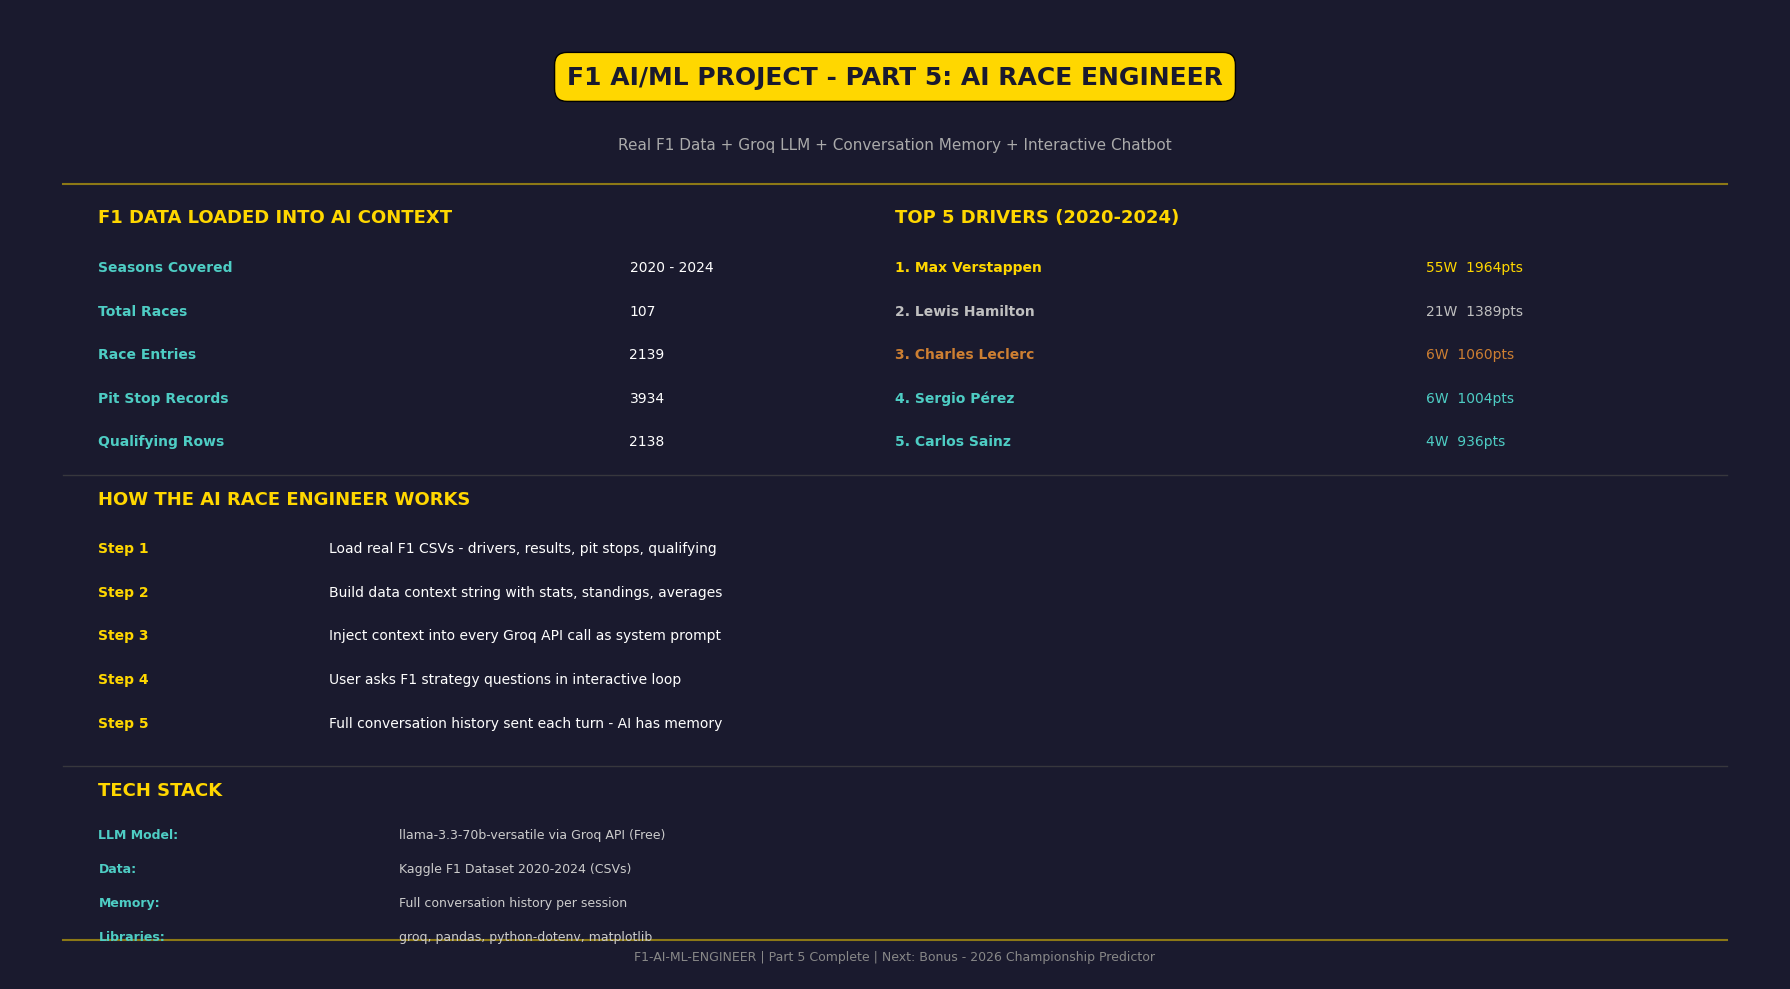

Saved: part5_summary_card.png

PART 5 COMPLETE!
Model       : llama-3.3-70b-versatile (Groq)
Data loaded : 107 races | 2139 entries
Chat turns  : 5

Files in 05_ai_race_engineer/:
  race_engineer.ipynb                 [SAVED]
  chat_log.txt                        [SAVED]
  part5_summary_card.png              [SAVED]
  .env                                [SAVED]

Next up: Bonus - 2026 F1 Championship Predictor!


In [5]:
# Cell 4: Summary Card and Save Chat Log

import os
from datetime import datetime

print("Generating Part 5 Summary...")
print("="*60)

# ─────────────────────────────────────────────────────────────
# 1. SAVE CHAT LOG AS TEXT FILE
# ─────────────────────────────────────────────────────────────

chat_log = f"""F1 AI RACE ENGINEER - CHAT LOG
================================
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Model Used: llama-3.3-70b-versatile (Groq - Free)
Total Turns: {turn}

DEMO QUESTIONS ASKED:
1. Who has been the most dominant driver from 2020 to 2024 and why?
2. What is the ideal pit stop strategy for a 2-stop race at Monaco?
3. If Max Verstappen starts from P3 at Monza what strategy would you recommend to win?

DATA USED:
- Races analyzed  : {modern_races.shape[0]} (2020-2024)
- Race entries    : {modern_results.shape[0]}
- Pit stop records: {modern_pitstops.shape[0]}
- Qualifying rows : {modern_quali.shape[0]}

TOP DRIVERS IN CONTEXT:
{driver_stats[['full_name','wins','total_pts']].head(5).to_string(index=False)}

TOP CONSTRUCTORS IN CONTEXT:
{const_stats[['name','wins','total_pts']].head(5).to_string(index=False)}

HOW IT WORKS:
- Real F1 CSV data loaded and summarized
- Data context injected into every AI prompt
- Groq API (llama-3.3-70b-versatile) powers the responses
- Full conversation history sent each turn (AI has memory)
- Interactive loop allows unlimited questions
"""

with open('chat_log.txt', 'w', encoding='utf-8') as f:
    f.write(chat_log)

print("Saved: chat_log.txt")

# ─────────────────────────────────────────────────────────────
# 2. SUMMARY CARD
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(18, 10))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title bar
title_box = dict(boxstyle='round,pad=0.5', facecolor='#FFD700', alpha=1.0)
ax.text(5, 9.3, 'F1 AI/ML PROJECT - PART 5: AI RACE ENGINEER',
        ha='center', va='center', fontsize=18,
        fontweight='bold', color='#1a1a2e', bbox=title_box)

ax.text(5, 8.6,
        'Real F1 Data + Groq LLM + Conversation Memory + Interactive Chatbot',
        ha='center', va='center', fontsize=11, color='#aaaaaa')

# Divider
ax.plot([0.3, 9.7], [8.2, 8.2], color='#FFD700', linewidth=1.5, alpha=0.5)

# ── Section 1: Data Stats ────────────────────────────────────
ax.text(0.5, 7.8, 'F1 DATA LOADED INTO AI CONTEXT',
        fontsize=13, fontweight='bold', color='#FFD700')

data_stats = [
    ('Seasons Covered',  '2020 - 2024'),
    ('Total Races',      str(modern_races.shape[0])),
    ('Race Entries',     str(modern_results.shape[0])),
    ('Pit Stop Records', str(modern_pitstops.shape[0])),
    ('Qualifying Rows',  str(modern_quali.shape[0])),
]

col1_x = 0.5
col2_x = 3.5
col3_x = 5.5
col4_x = 8.0

for i, (label, value) in enumerate(data_stats):
    y = 7.3 - i * 0.45
    ax.text(col1_x, y, label, fontsize=10, color='#4ecdc4', fontweight='bold')
    ax.text(col2_x, y, value, fontsize=10, color='white')

# ── Section 2: Top Drivers ───────────────────────────────────
ax.text(5.0, 7.8, 'TOP 5 DRIVERS (2020-2024)',
        fontsize=13, fontweight='bold', color='#FFD700')

top5 = driver_stats.head(5)
gold_colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#4ecdc4', '#4ecdc4']

for i, (_, row) in enumerate(top5.iterrows()):
    y = 7.3 - i * 0.45
    color = gold_colors[i]
    ax.text(5.0, y, f"{i+1}. {row['full_name']}",
            fontsize=10, color=color, fontweight='bold')
    ax.text(8.0, y, f"{int(row['wins'])}W  {int(row['total_pts'])}pts",
            fontsize=10, color=color)

# Divider
ax.plot([0.3, 9.7], [5.2, 5.2], color='#444', linewidth=1, alpha=0.7)

# ── Section 3: How It Works ──────────────────────────────────
ax.text(0.5, 4.9, 'HOW THE AI RACE ENGINEER WORKS',
        fontsize=13, fontweight='bold', color='#FFD700')

steps = [
    ('Step 1', 'Load real F1 CSVs - drivers, results, pit stops, qualifying'),
    ('Step 2', 'Build data context string with stats, standings, averages'),
    ('Step 3', 'Inject context into every Groq API call as system prompt'),
    ('Step 4', 'User asks F1 strategy questions in interactive loop'),
    ('Step 5', 'Full conversation history sent each turn - AI has memory'),
]

for i, (step, desc) in enumerate(steps):
    y = 4.4 - i * 0.45
    ax.text(0.5, y, step, fontsize=10, color='#FFD700', fontweight='bold')
    ax.text(1.8, y, desc, fontsize=10, color='white')

# Divider
ax.plot([0.3, 9.7], [2.2, 2.2], color='#444', linewidth=1, alpha=0.7)

# ── Section 4: Tech Stack ────────────────────────────────────
ax.text(0.5, 1.9, 'TECH STACK',
        fontsize=13, fontweight='bold', color='#FFD700')

stack = [
    ('LLM Model', 'llama-3.3-70b-versatile via Groq API (Free)'),
    ('Data',      'Kaggle F1 Dataset 2020-2024 (CSVs)'),
    ('Memory',    'Full conversation history per session'),
    ('Libraries', 'groq, pandas, python-dotenv, matplotlib'),
]

for i, (tech, desc) in enumerate(stack):
    y = 1.45 - i * 0.35
    ax.text(0.5, y, f"{tech}:", fontsize=9,
            color='#4ecdc4', fontweight='bold')
    ax.text(2.2, y, desc, fontsize=9, color='#cccccc')

# Footer
ax.plot([0.3, 9.7], [0.4, 0.4], color='#FFD700', linewidth=1.5, alpha=0.5)
ax.text(5, 0.2,
        'F1-AI-ML-ENGINEER | Part 5 Complete | Next: Bonus - 2026 Championship Predictor',
        ha='center', fontsize=9, color='#888888')

plt.tight_layout()
plt.savefig('part5_summary_card.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: part5_summary_card.png")

# ─────────────────────────────────────────────────────────────
# 3. FINAL PRINT
# ─────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("PART 5 COMPLETE!")
print("="*60)
print(f"Model       : llama-3.3-70b-versatile (Groq)")
print(f"Data loaded : {modern_races.shape[0]} races | {modern_results.shape[0]} entries")
print(f"Chat turns  : {turn}")
print("\nFiles in 05_ai_race_engineer/:")
for fname in ['race_engineer.ipynb', 'chat_log.txt',
              'part5_summary_card.png', '.env']:
    exists = 'SAVED' if os.path.exists(fname) else 'MISSING'
    print(f"  {fname:<35} [{exists}]")
print("\nNext up: Bonus - 2026 F1 Championship Predictor!")